In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

print('Data Types:', df.dtypes)

print('Missing Values:', df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Descriptive statistics:', df.describe())


Shape: (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Data Types: Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber             

2 Overall Workforce

In [10]:
print("Attrition counts:")
print(df["Attrition"].value_counts())

print("Department counts:")
print(df["Department"].value_counts())

print("Overall Attrition", round((df["Attrition"]=="Yes").mean()*100,1),"%")

Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Department counts:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
Overall Attrition 16.1 %


Bar Chart 1 Employees by Department

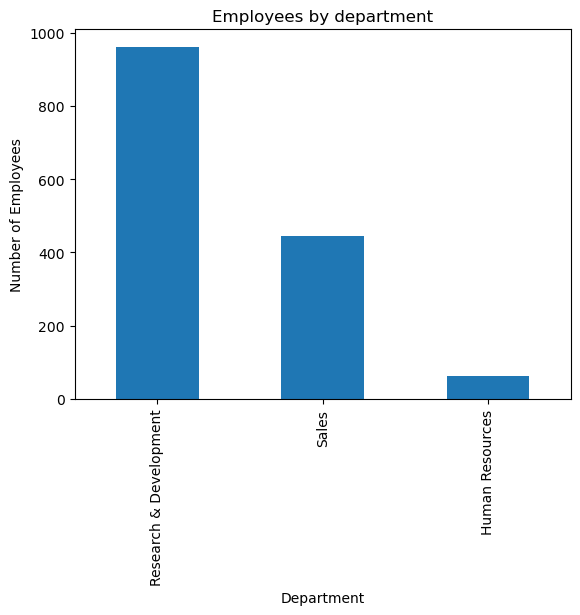

In [11]:
df["Department"].value_counts().plot(kind="bar")
plt.title("Employees by department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

Interpretation: Research and Development is the largest department, follwed by Sales and Human Resources. Therefore, R&D contributes the largest number of employess to the overall workforce.

Bar Chart 2 Employees by Job Role

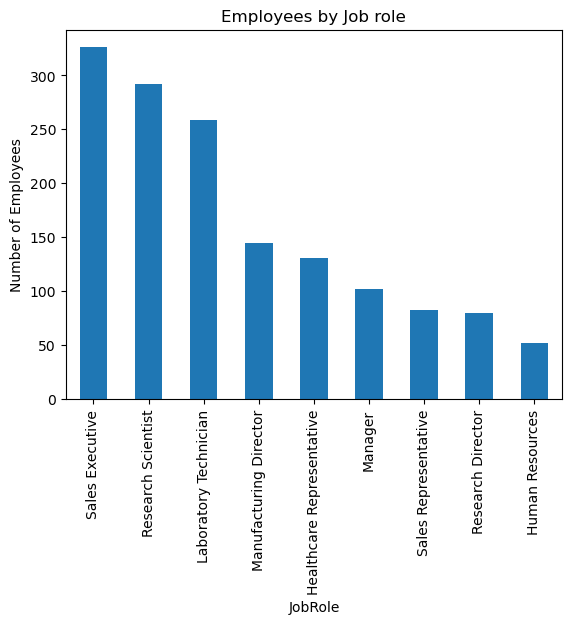

In [15]:
df["JobRole"].value_counts().plot(kind="bar")
plt.title("Employees by Job role")
plt.xlabel("JobRole")
plt.ylabel("Number of Employees")
plt.show()

Interpretation: Employees are spread across technical, sales, operational, and management roles. Job role size is important when interpreting turnover because a small role can have a high percentage attrition rate without producing the largest number of exits.

Bar Chart 3: Department Attrition

Department
Sales                     20.6%
Human Resources           19.0%
Research & Development    13.8%
Name: Yes, dtype: object


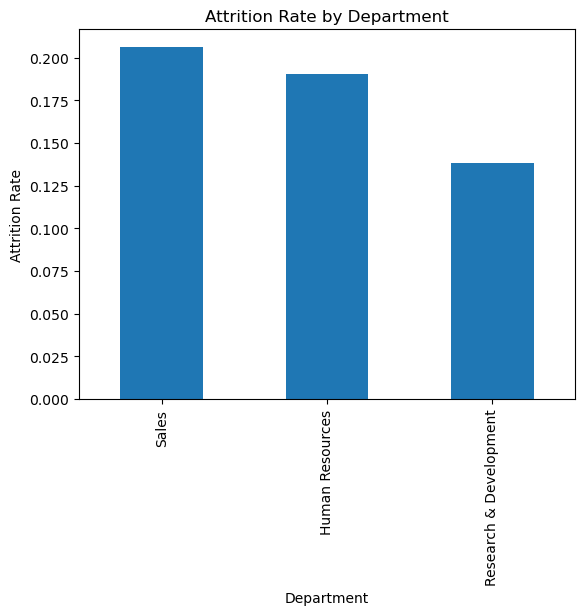

In [16]:
dept_attrition = pd.crosstab(df["Department"], df["Attrition"], normalize="index")["Yes"].sort_values(ascending=False)
print((dept_attrition*100).round(1).astype(str)+"%")
dept_attrition.plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate")
plt.show()

Interpretation: Sales has the higest observed departmental attrition rate, followed by Human Resources. Research and Development has the lowest rate.

Bar Chart 4: Age and Attrition

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64


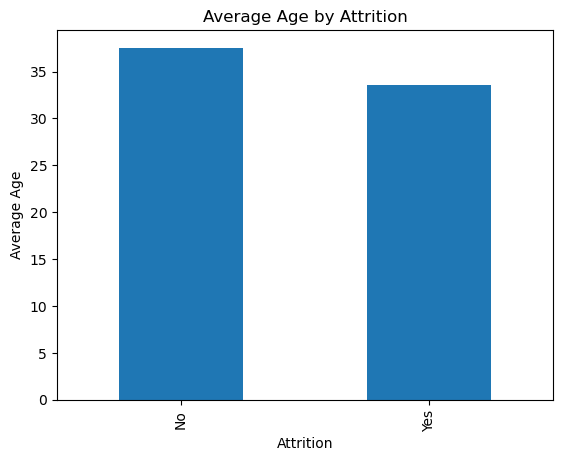

In [18]:
print(df.groupby("Attrition")["Age"].mean())
df.groupby("Attrition")["Age"].mean().plot(kind="bar")
plt.title("Average Age by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Age")
plt.show()

Histogram Chart 1: Age

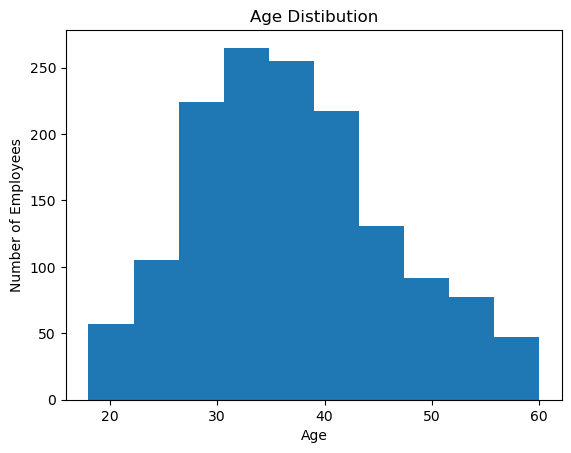

In [19]:
plt.hist(df["Age"], bins=10)
plt.title("Age Distibution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()

Interpretation: The age distribution shows how employees are spread across age groups. Younger employees show higher observed attrition in this dataset, making a candidate variable for further analysis.

Monthly Income and Retention

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


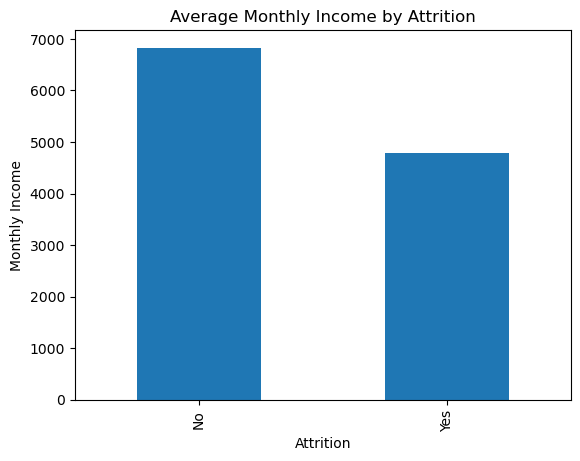

In [20]:
print(df.groupby("Attrition")["MonthlyIncome"].mean())
df.groupby("Attrition")["MonthlyIncome"].mean().plot(kind="bar")
plt.title("Average Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

Histogram 2: Monthly Income

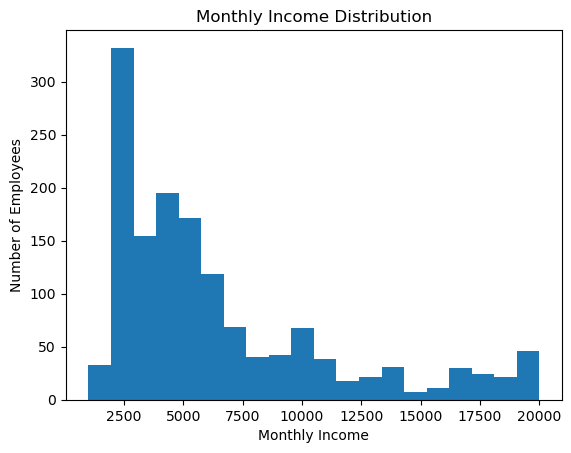

In [22]:
plt.hist(df["MonthlyIncome"],bins=20)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")
plt.show()

Interpretation: Monthly Income is concentrated toward lower values with fewer employees at substantially higher income levels.

Boxplot 1: Monthly Income by Attrition

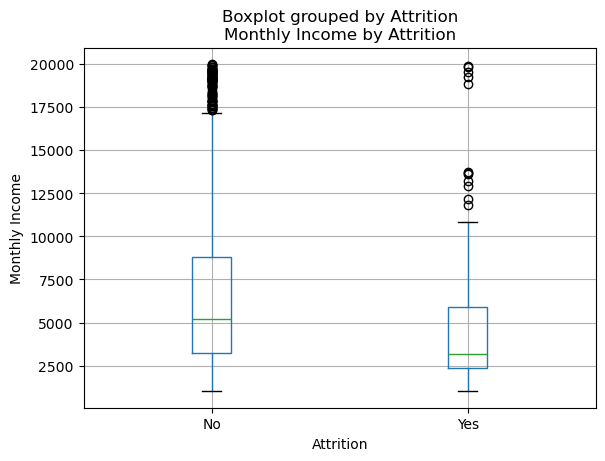

In [23]:
df.boxplot(column="MonthlyIncome", by="Attrition")
plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

Interpretation: Employees who left have a lower income distribution than employees who stayed. This makes monthly income a useful candidate feature for future modelling.

Overtime and Attrition

OverTime
No     10.4%
Yes    30.5%
Name: Yes, dtype: object


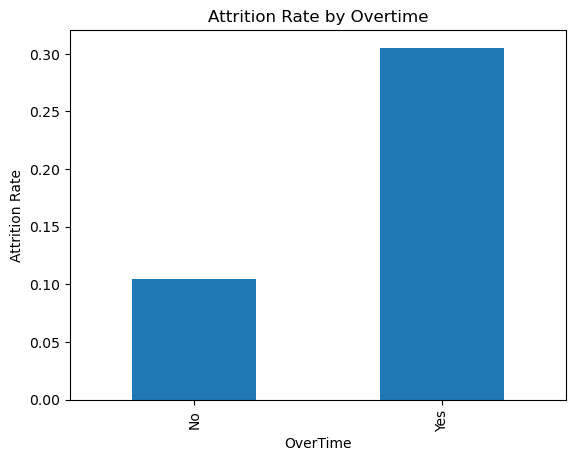

In [29]:
overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"],normalize="index")["Yes"]
print((overtime_attrition*100).round(1).astype(str)+"%")
overtime_attrition.plot(kind="bar")
plt.title("Attrition Rate by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate")
plt.show()

Interpretation: Overtime employees have a much higher observed attrition rate than employees who do not work overtime. This is one of the strongest patterns identifies in the initial exploration.

Job role Turnover

JobRole
Sales Representative         39.8%
Laboratory Technician        23.9%
Human Resources              23.1%
Sales Executive              17.5%
Research Scientist           16.1%
Manufacturing Director        6.9%
Healthcare Representative     6.9%
Manager                       4.9%
Research Director             2.5%
Name: Yes, dtype: object


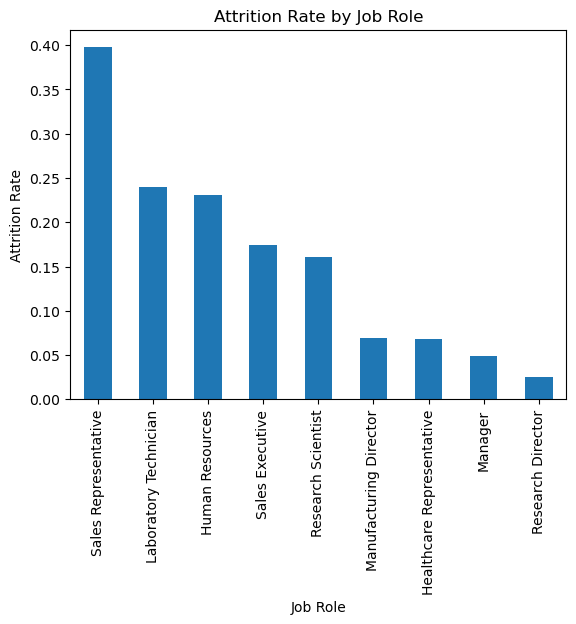

In [32]:
role_attrition = pd.crosstab(df["JobRole"], df["Attrition"],normalize="index")["Yes"].sort_values(ascending=False)
print((role_attrition*100).round(1).astype(str)+"%")
role_attrition.plot(kind="bar")
plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate")
plt.show()

Interpretation: Sales representative have the highest observed job-role attrition rate, followed by Laboratory Technicians and Human resources roles

Boxplot 2 Age by Attrition

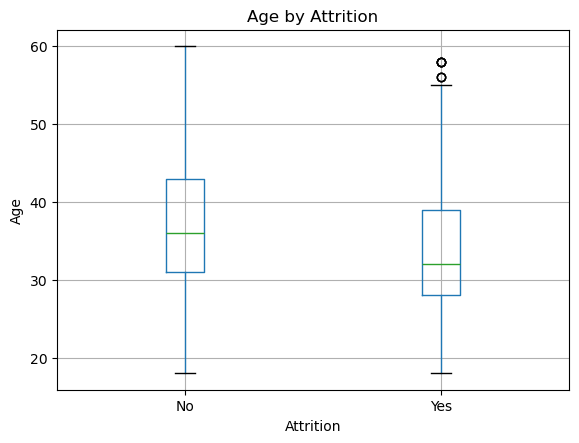

In [34]:
df.boxplot(column="Age",by="Attrition")
plt.title("Age by Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

Interpretation: The age boxplot provides a second view of the difference between employees who stayed and those who left and supports the observation that the attrition group tends to be younger.

Pie Chart - Overall Attrition

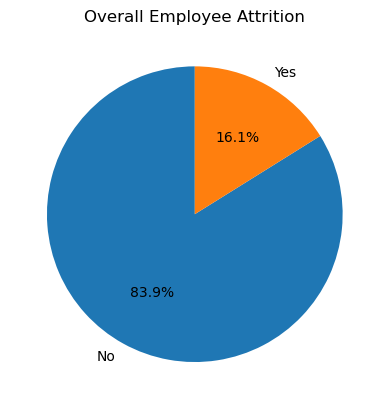

In [35]:
df["Attrition"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Overall Employee Attrition")
plt.ylabel("")
plt.show()